# Text Representation

Text representation in NLP means converting text into a numerical form that a machine learning model can understand and process.

## What is Embedding?

Embeddings in NLP is a technique where individual words are represented as real-valued vectors and captures inter-word semantics.


In this notebook, We going to intreduce 2 techniques for embedding. These techniques will be used for a machine learning models such as SVM, Random forest, ... ect.

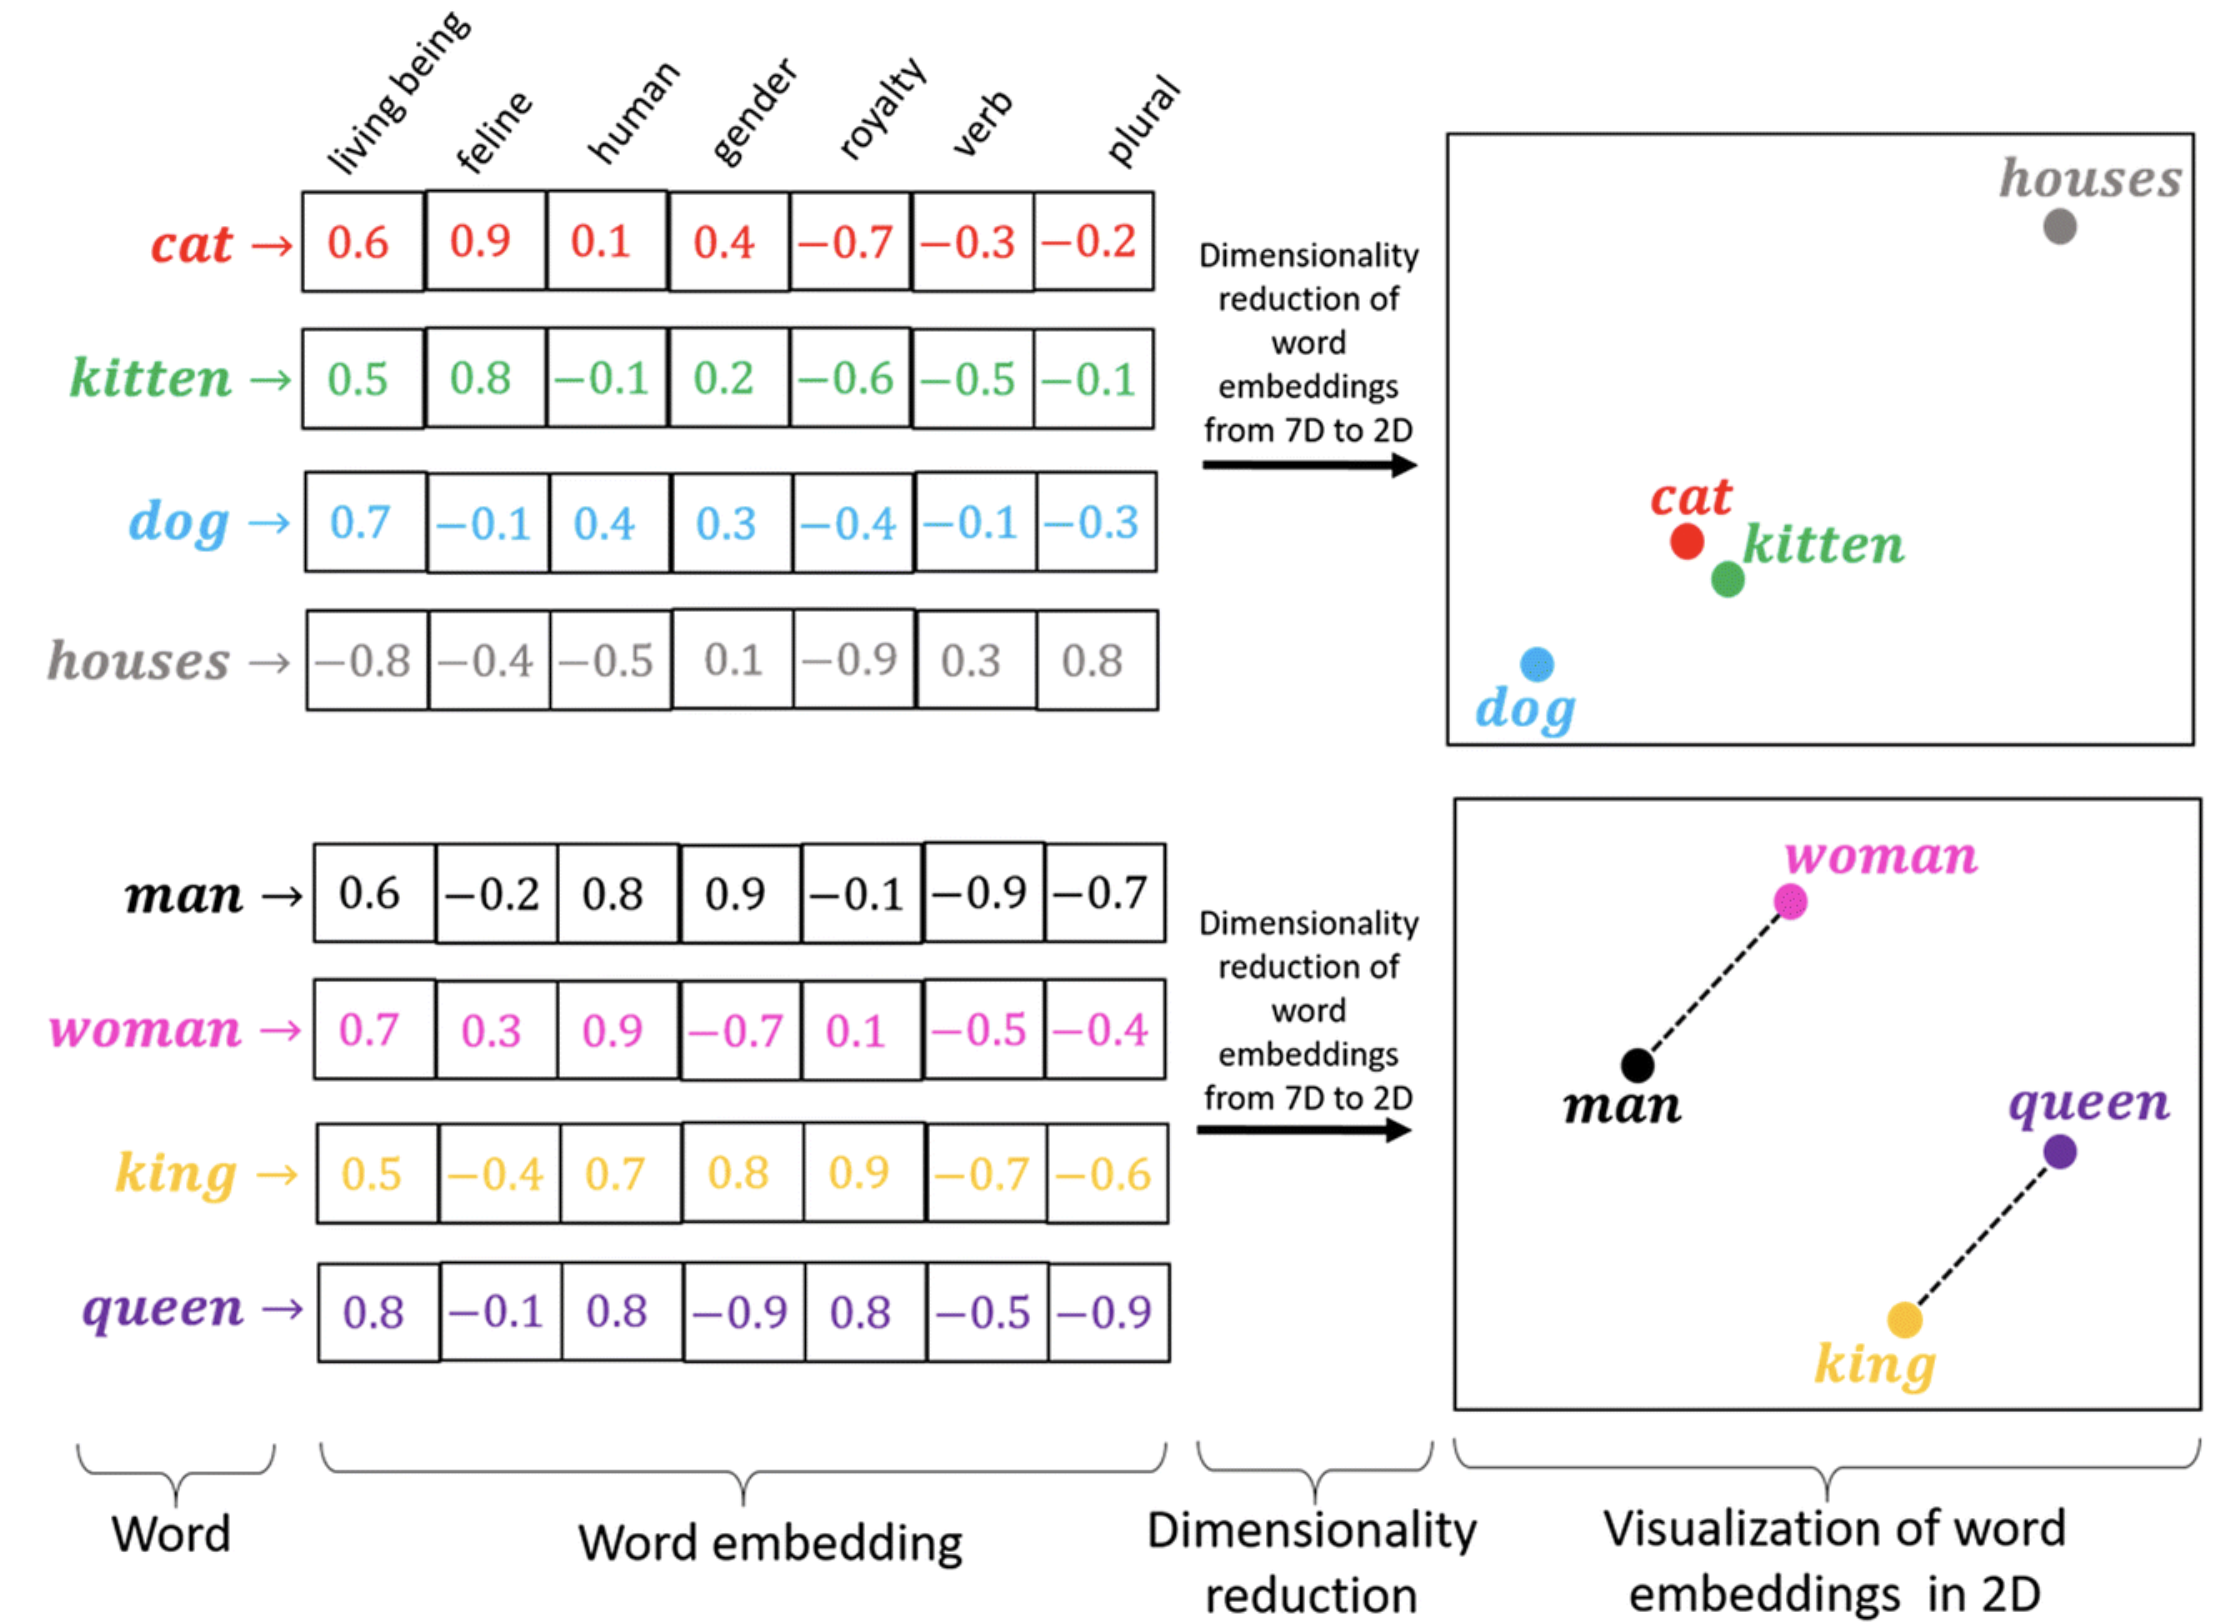

<img src="https://drive.google.com/uc?export=view&id=1jd0u_sGppDKqBYbhtJfGxp14lnUWUTTw" width="900">

# 1- TF-IDF

<img src="https://drive.google.com/uc?export=view&id=1saSt0mMgOQ2ybbTms1lu_ruhUcBWkKzL" width="500">

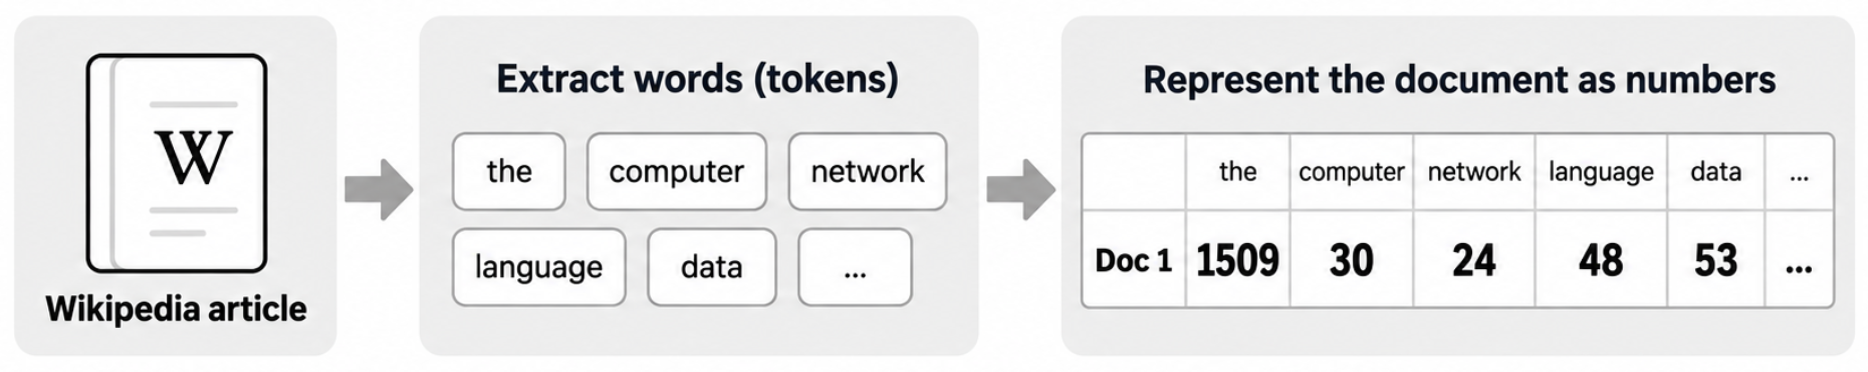

TF-IDF stands for term frequency-inverse document frequency. It is a measure that discounts common words. Used in the fields of information retrieval (IR) and machine learning, that can quantify the importance of words in a document amongst a collection of documents (also known as a corpus).

### Components of TF-IDF

1. **TF (Term Frequency):**  
   Measures how frequently a term appears in a document.


$$ \text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d} $$


2. **IDF (Inverse Document Frequency):**  
   Measures how important a term is across all documents. Words that appear in many documents get lower scores.

$$    \text{IDF}(t) = \log \left(\frac{\text{Number of all documents N}}{\text{Number of documents containing the term } t}\right) $$

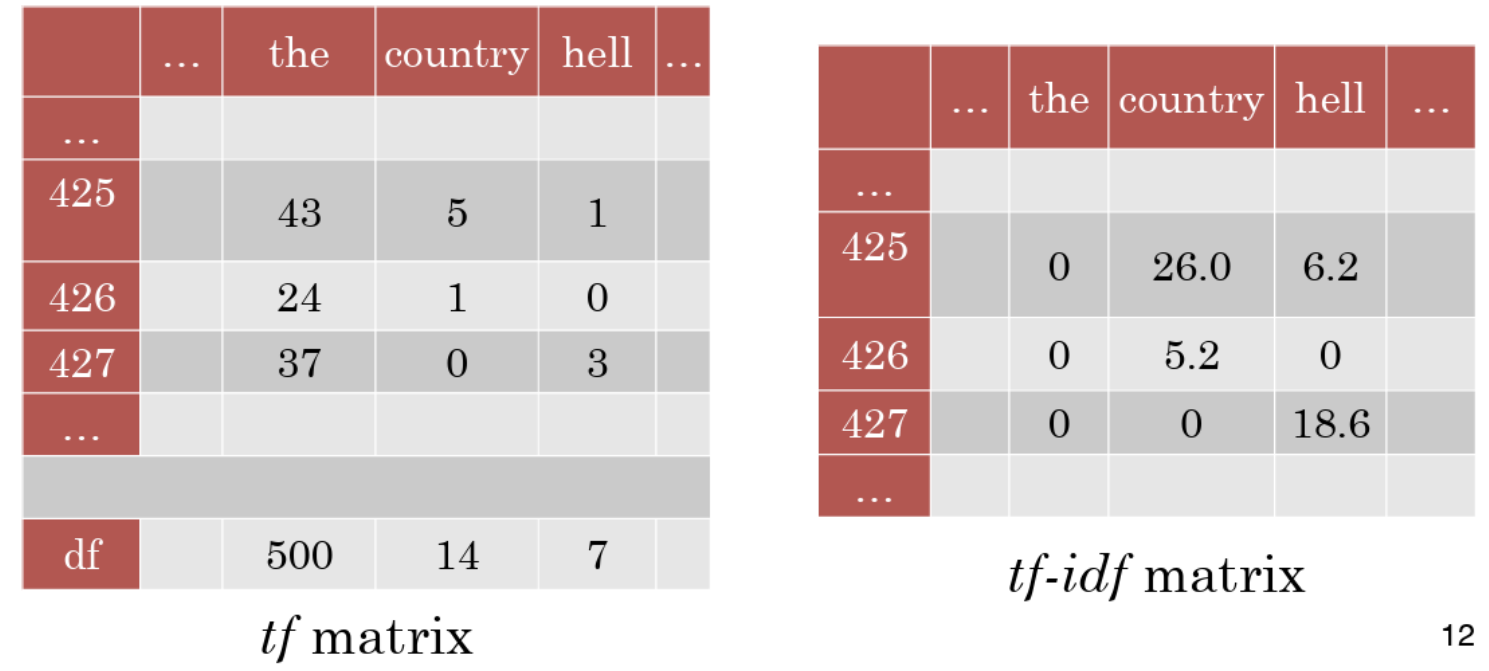

<img src="https://drive.google.com/uc?export=view&id=1JqPILC8TTh3yDQZCSuPNXwm6ER5YeJFh" width="900">

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]


In [3]:
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(data) # returns sparce matrix

In [5]:
import pandas as pd
df = pd.DataFrame(result.toarray(), columns=tfidf.get_feature_names_out())
df

,data,digital,economy,is,new,of,oil,the
0,0.243777,0.34262,0.34262,0.243777,0.000000,0.34262,0.243777,0.68524
1,0.448321,0.00000,0.00000,0.448321,0.630099,0.00000,0.448321,0.00000


# Cosine similarity

In NLP, Cosine similarity is a metric used to measure how similar the documents are.


$$ \text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|} $$

Where:  
$ A \cdot B $  = dot product of vectors A and B  
$ \|A\| $ = magnitude (length) of vector A  
$ \|B\| $ =  magnitude (length) of vector B

#### Intuition

- If vectors point in the **same direction**, cosine similarity = **1** (maximum similarity).
- If vectors are **orthogonal (90° apart)**, cosine similarity = **0** (no similarity).

<img src="https://drive.google.com/uc?export=view&id=1b-o8CVfHBsjUGY_hXmxevU91gHidIuxO" width="900">

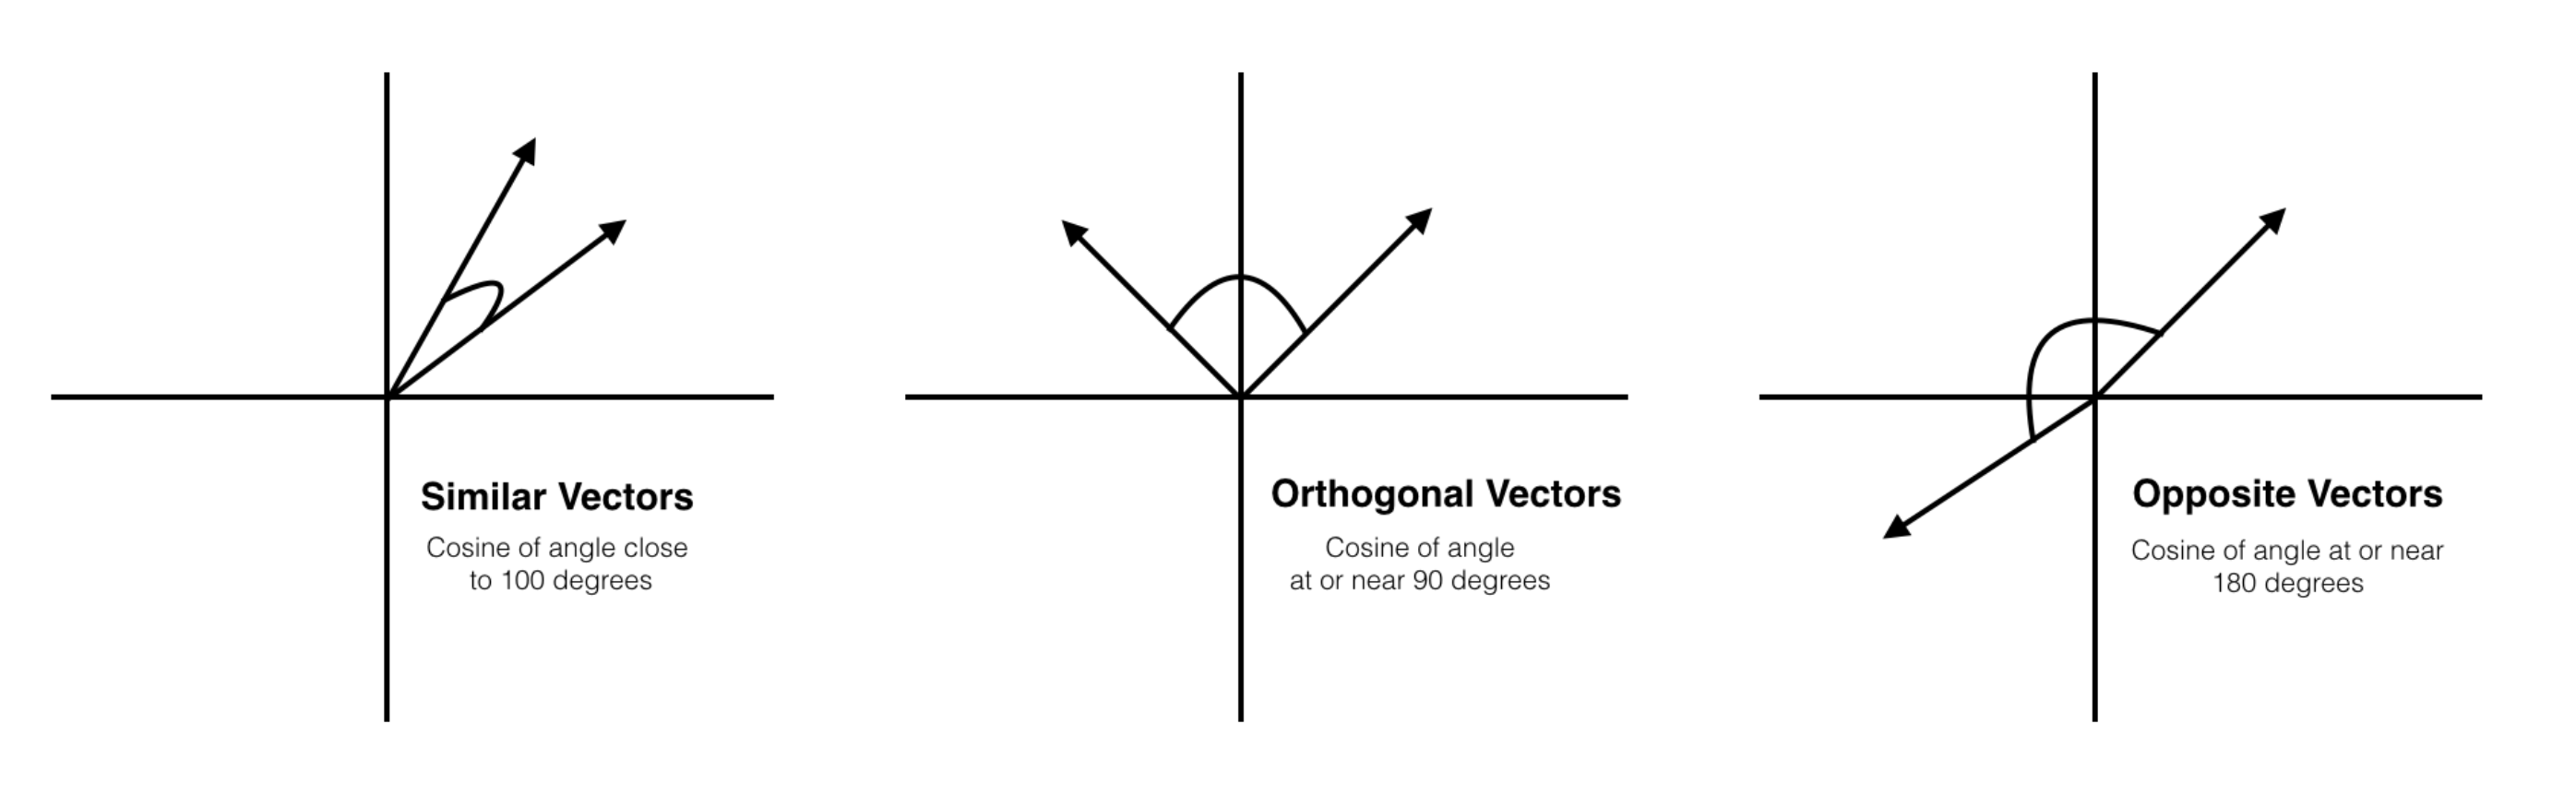

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
# Sample text data (replace with your own documents)

doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]

In [8]:
tfidf_vectorizer = TfidfVectorizer() # Create a CountVectorizer instance
vector_matrix = tfidf_vectorizer.fit_transform(data) # Fit and transform the documents into numerical vectors

In [10]:
# Calculate the cosine similarity between the documents
cosine_similarity_matrix = cosine_similarity(vector_matrix)

df_cosine = pd.DataFrame(data=cosine_similarity_matrix, index=data, columns=data)

df_cosine

,Data is the oil of the digital economy,Data is a new oil
Data is the oil of the digital economy,1.000000,0.327871
Data is a new oil,0.327871,1.000000


# 2- What is Word2vec?

Word2Vec consists of models for generating word embedding. These models are two-layer neural networks having one input layer, one hidden layer, and one output layer.

Word2Vec utilizes two architectures :
1. CBOW (Continuous Bag of Words)
2. **Skip Gram**
<img src="https://drive.google.com/uc?export=view&id=1K38nEu_KhgtSJuG2RySwc6U5AAjVAgWZ" width="600">


Run this command in terminal to install
> pip install gensim

We will use fake and real news dataset to do our expirament. You can find the dataset here: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset?select=True.csv


In [13]:
%pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 2.8 MB/s eta 0:00:09
   -- ------------------------------------- 1.3/24.4 MB 2.8 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/24.4 MB 2.7 MB/s eta 0:00:09
   ---- ----------------------------------- 2.6/24.4 MB 2.8 MB/s eta 0:00:08
   ----- ---------------------------------- 3.4/24.4 MB 2.9 MB/s eta 0:00:08
   ------ --------------------------------- 3.9/24.4 MB 2.9 MB/s eta 0:00:08
   ------- -------------------------------- 4.7/24.4 MB 2.9 MB/s eta 0:00:07
   -------- ------------------------------- 5.2/24.4 MB 2.9 MB/s eta 0:00:07
   --------- ------------------------------ 6.0/24.4 MB 2.9 MB/s eta 0:00:07
   ---------- ----------------------------- 6.6/24.4 MB 3.0 MB/s eta 0:00:07
   ------------ ----

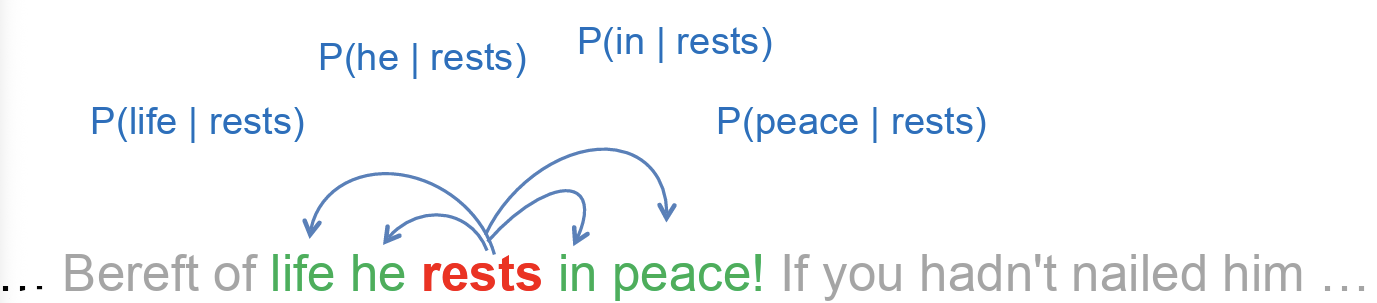

In [14]:
import pandas as pd
import nltk
import numpy as np
import gensim

from nltk.tokenize import word_tokenize

In [16]:
df = pd.read_csv('True.csv', engine='python', on_bad_lines='skip') #fake-and-real-news-dataset-true.csv
df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [17]:
tokens = []

for i in df['text']:
    token = word_tokenize(i)
    tokens.append(token)

In [18]:
# 'tokens' are the vatiable U want to convert to vec
# min_count=1 --> if this word apeared 1 or more times convert it to vector
# vector_size=100 --> each vector is 100 
# window=5 --> how many words does this word has to match
# sg=1 --> skip gram = True

w2v = gensim.models.Word2Vec(tokens, min_count=1, vector_size=100, window=5, sg=1)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [19]:
print("Cosine similarity between 'provide' and 'program' - Skip Gram : ",w2v.wv.similarity('provide', 'program'))

Cosine similarity between 'provide' and 'program' - Skip Gram :  0.3959276


In [20]:
print("words that similar to 'program' - Skip Gram : ",w2v.wv.most_similar('program'))

words that similar to 'program' - Skip Gram :  [('programme', 0.7979333400726318), ('programs', 0.7726149559020996), ('arsenal', 0.6961310505867004), ('restraints', 0.6891002655029297), ('bond-buying', 0.6874566078186035), ('programmes', 0.6773433685302734), ('Deferred', 0.6702121496200562), ('terminating', 0.6634228229522705), ('mandate.', 0.6615488529205322), ('EB-5', 0.6614843606948853)]


# Tasks

### Task 1: Cosine Similarity
Use the Cosine Similarity method to determine how similar the following sentences are.

'This is the first document.',  
'This document is the second document.',  
'And this is the third one.',  
'Is this the first document?'  


In [24]:
doc = ['This is the first document.',  
'This document is the second document.',  
'And this is the third one.',  
'Is this the first document?']

tfidf_vectorizer = TfidfVectorizer() # Create a CountVectorizer instance
vector_matrix = tfidf_vectorizer.fit_transform(doc) # Fit and transform the documents into numerical vectors

# Calculate the cosine similarity between the documents
cosine_similarity_matrix = cosine_similarity(vector_matrix)

df_cosine = pd.DataFrame(data=cosine_similarity_matrix, index=doc, columns=doc)

df_cosine

,This is the first document.,This document is the second document.,And this is the third one.,Is this the first document?
This is the first document.,1.000000,0.646926,0.307772,1.000000
This document is the second document.,0.646926,1.000000,0.225240,0.646926
And this is the third one.,0.307772,0.225240,1.000000,0.307772
Is this the first document?,1.000000,0.646926,0.307772,1.000000


### Task 2: TF-IDF
Use tf-idf method on the sentences below to determine the important words.

'data science is one of the most important fields of science',  
'this is one of the best data science courses',  
'data scientists analyze data'  


In [26]:
doc2 = ['data science is one of the most important fields of science',  
'this is one of the best data science courses',  
'data scientists analyze data']

vector_matrix = tfidf_vectorizer.fit_transform(doc2)

for word, idx in tfidf_vectorizer.vocabulary_.items():
    print(word, vector_matrix[0, idx], vector_matrix[1, idx], vector_matrix[2, idx])

data 0.18952580966166682 0.2364200460658773 0.6410554491745127
science 0.4880979747364737 0.30443385488725433 0.0
is 0.24404898736823685 0.30443385488725433 0.0
one 0.24404898736823685 0.30443385488725433 0.0
of 0.4880979747364737 0.30443385488725433 0.0
the 0.24404898736823685 0.30443385488725433 0.0
most 0.32089509027199203 0.0 0.0
important 0.32089509027199203 0.0 0.0
fields 0.32089509027199203 0.0 0.0
this 0.0 0.40029393442429256 0.0
best 0.0 0.40029393442429256 0.0
courses 0.0 0.40029393442429256 0.0
scientists 0.0 0.0 0.5427006131762078
analyze 0.0 0.0 0.5427006131762078


## Word2vec

### Task 3:

Download the Simpsons dataset **(simpsons_script_lines.csv)** and apply the preprocessing procedure.  
Use the **'spoken_words'** column.
```
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[0-9]", '', text)
    text = re.sub(r"[)(,”“.’$-]", '', text)
    return text
```
Create a skip gram Word2Vec model as below.
```
Skip_gram_model = gensim.models.Word2Vec(tokens, min_count = 1, vector_size = 100, window = 5, sg = 1)

In [37]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[0-9]", '', text)
    text = re.sub(r"[)(,”“.’$-]", '', text)
    return text


df = pd.read_csv('dataset\simpsons_script_lines.csv', engine='python', on_bad_lines='skip') 
df.head()


,raw_character_text,spoken_words
0,Miss Hoover,"No, actually, it was a little of both. Sometim..."
1,Lisa Simpson,Where's Mr. Bergstrom?
2,Miss Hoover,I don't know. Although I'd sure like to talk t...
3,Lisa Simpson,That life is worth living.
4,Edna Krabappel-Flanders,The polls will be open from now until the end ...


In [39]:
tokens = []

for i in df['spoken_words']:
    if pd.isna(i):
        continue
    i = clean_text(i)
    token = word_tokenize(i)
    tokens.append(token)


In [40]:
Skip_gram_model = gensim.models.Word2Vec(tokens, min_count = 1, vector_size = 100,
 window = 5, sg = 1)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


### Task 4

Use: wv.most_similar() method to :

1.	Find the words similar to “homer”.

2.	Find the words similar to “marge”.

3. Find the words similar to “bart”



In [41]:
print("words that similar to 'homer' - Skip Gram : ",Skip_gram_model.wv.most_similar('homer'))
print("words that similar to 'marge' - Skip Gram : ",Skip_gram_model.wv.most_similar('marge'))
print("words that similar to 'bart' - Skip Gram : ",Skip_gram_model.wv.most_similar('bart'))


words that similar to 'homer' - Skip Gram :  [('abe', 0.8964220285415649), ('marge', 0.8784716129302979), ('grampa', 0.8301922678947449), ('eliza', 0.8288094997406006), ('bartholomew', 0.8262652158737183), ('mister', 0.8242598176002502), ('ned', 0.8239536285400391), ('waylon', 0.8137568831443787), ('barney', 0.8136546611785889), ('lurleen', 0.8126175403594971)]
words that similar to 'marge' - Skip Gram :  [('homer', 0.8784714937210083), ('abe', 0.8778578639030457), ('sweetie', 0.8460366725921631), ('eliza', 0.8318594098091125), ('lurleen', 0.8260911107063293), ('lisa', 0.8259431719779968), ('becky', 0.8228765726089478), ('sweetheart', 0.820669949054718), ('maude', 0.8143348097801208), ('neddy', 0.8103890419006348)]
words that similar to 'bart' - Skip Gram :  [('milhouse', 0.8767287731170654), ('lisa', 0.8453826308250427), ('abe', 0.825043261051178), ('eliza', 0.8235723972320557), ('jessica', 0.8202653527259827), ('sweetie', 0.816769540309906), ('grampa', 0.8151603937149048), ('laddie',

### Task 5

Use the wv.doesnt_match() method to :

1.	Find which of 'jimbo', 'milhouse’, and 'kearney’ does not belong to the list.

3.	Find the odd one among "nelson", "bart", and "milhouse".

4.	Find the odd one among ‘homer', 'patty', and ‘selma'.

*Hint: You need to pass the strings as List*

In [47]:
list1=['jimbo', 'milhouse',  'kearney']
list2=["nelson", "bart", "milhouse"]
list3=['homer', 'patty',  'selma']

print(f"word that doesnt mach in {list1} - Skip Gram : "
,Skip_gram_model.wv.doesnt_match(list1))

print(f"word that doesnt mach in {list2} - Skip Gram : "
,Skip_gram_model.wv.doesnt_match(list2))

print(f"word that doesnt mach in {list3} - Skip Gram : "
,Skip_gram_model.wv.doesnt_match(list3))

word that doesnt mach in ['jimbo', 'milhouse', 'kearney'] - Skip Gram :  milhouse
word that doesnt mach in ['nelson', 'bart', 'milhouse'] - Skip Gram :  nelson
word that doesnt mach in ['homer', 'patty', 'selma'] - Skip Gram :  homer
